# 🧬 Cancer type classification from RNA-Seq gene expression
> **Bioprocess & Bioengineering Portfolio | Machine Learning**  
> **Dataset:** TCGA RNA-Seq / 801 patients × 20,531 genes  
> **Task:** 4-class cancer type classification with Explainable AI

---

## 📖 Motivation

Every year, ~3-5% of cancer patients receive a **Cancer of Unknown Primary (CUP)** diagnosis the tissue of origin cannot be identified by conventional pathology. This delays or prevents effective treatment.

**RNA-Seq gene expression** captures a tumor's molecular fingerprint across all ~20,531 human genes. Even after metastasis, a cancer retains the *gene expression accent* of its origin tissue.

**Research question:** Can machine learning distinguish 5 cancer types from RNA-Seq profiles alone and identify *which genes* drive each classification?

| Code | Cancer | Tissue of Origin |
|------|--------|-----------------|
| BRCA | Breast Invasive Carcinoma | Breast |
| KIRC | Kidney Renal Clear Cell Carcinoma | Kidney |
| COAD | Colon Adenocarcinoma | Colon |
| LUAD | Lung Adenocarcinoma | Lung |
| PRAD | Prostate Adenocarcinoma | Prostate |

---

## 🔬 What Makes This Study Stand Out

1. **PCA vs UMAP** :side-by-side comparison of linear vs non-linear dimensionality reduction
2. **SMOTE class balancing** : addresses BRCA (n=300) vs COAD (n=78) imbalance, measures per-class impact
3. **SHAP biological validation** : over-expressed vs under-expressed genes mapped per cancer type


---
## 1.  Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import warnings, os, glob, copy
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
import umap.umap_ as umap_
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc)

import shap
import kagglehub

# Global style
plt.rcParams.update({
    'font.weight':       'normal',
    'axes.titleweight':  'normal',
    'axes.labelweight':  'normal',
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.dpi':        120,
})
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.0)

COLORS       = sns.color_palette('Set2', 5)
CANCER_TYPES = ['BRCA', 'KIRC', 'COAD', 'LUAD', 'PRAD']

print('✅ All libraries loaded.')


✅ All libraries loaded.


---
## 2.  Load dataset

**Source:** [Kaggle — Gene Expression Cancer RNA-Seq](https://www.kaggle.com/datasets/waalbannyantudre/gene-expression-cancer-rna-seq-donated-on-682016)

Requires `kaggle.json` in `~/.config/kaggle/`.

In [2]:
print('⬇️  Fetching dataset...')
path = kagglehub.dataset_download(
    'waalbannyantudre/gene-expression-cancer-rna-seq-donated-on-682016'
)
print(f'✅ Cached at: {path}')
for f in sorted(os.listdir(path)):
    print(f'   {f}  ({os.path.getsize(os.path.join(path,f))/1e6:.1f} MB)')


⬇️  Fetching dataset...


100%|██████████| 70.6M/70.6M [00:00<00:00, 147MB/s]

Extracting files...


✅ Cached at: /root/.cache/kagglehub/datasets/waalbannyantudre/gene-expression-cancer-rna-seq-donated-on-682016/versions/1
   data.csv  (206.2 MB)
   labels.csv  (0.0 MB)


In [3]:
all_csvs   = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)
DATA_PATH  = next(f for f in all_csvs
                  if 'data' in os.path.basename(f).lower()
                  and 'label' not in os.path.basename(f).lower())
LABEL_PATH = next(f for f in all_csvs if 'label' in os.path.basename(f).lower())

X_raw = pd.read_csv(DATA_PATH,  index_col=0)
y_raw = pd.read_csv(LABEL_PATH, index_col=0)
X_raw = X_raw.loc[y_raw.index]
y     = y_raw.iloc[:, 0]

print(f'Samples : {X_raw.shape[0]}')
print(f'Genes   : {X_raw.shape[1]:,}')
print(f'Classes : {sorted(y.unique().tolist())}')
print(f'Missing : {X_raw.isnull().sum().sum()}')
display(X_raw.iloc[:3, :5])


Samples : 801
Genes   : 20,531
Classes : ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']
Missing : 0


,gene_0,gene_1,gene_2,gene_3,gene_4
sample_0,0.0,2.017209,3.265527,5.478487,10.431999
sample_1,0.0,0.592732,1.588421,7.586157,9.623011
sample_2,0.0,3.511759,4.327199,6.881787,9.870730


---
## 3.  Exploratory data analysis

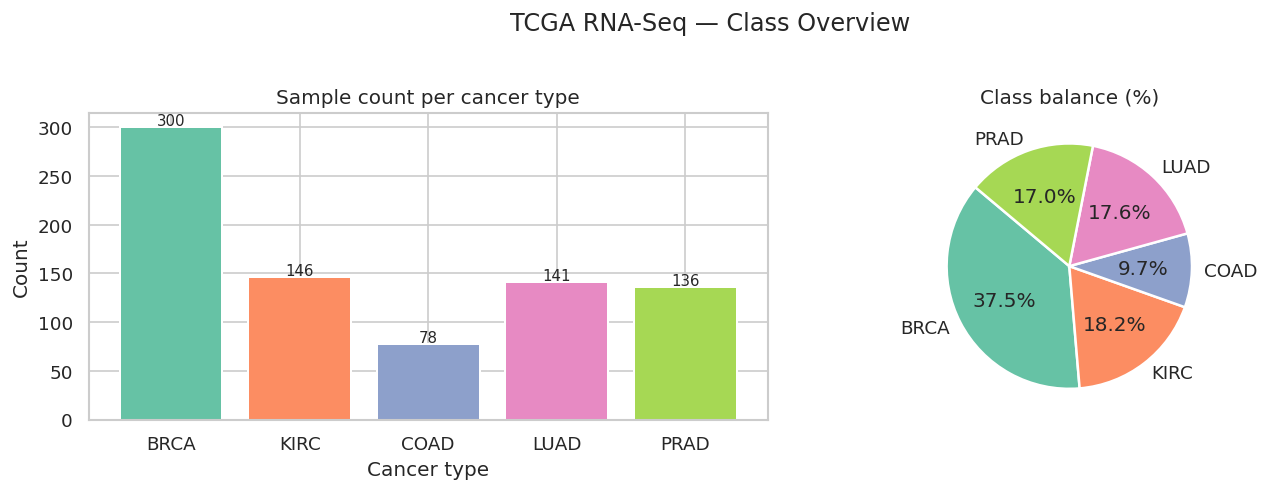

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = y.value_counts().reindex(CANCER_TYPES)
bars = axes[0].bar(counts.index, counts.values,
                   color=COLORS, edgecolor='white', linewidth=1.2)
axes[0].set_title('Sample count per cancer type')
axes[0].set_xlabel('Cancer type'); axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 2, str(val),
                 ha='center', fontsize=9)

axes[1].pie(counts.values, labels=counts.index, colors=COLORS,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Class balance (%)')

plt.suptitle('TCGA RNA-Seq — Class Overview', y=1.02)
plt.tight_layout(); plt.show()


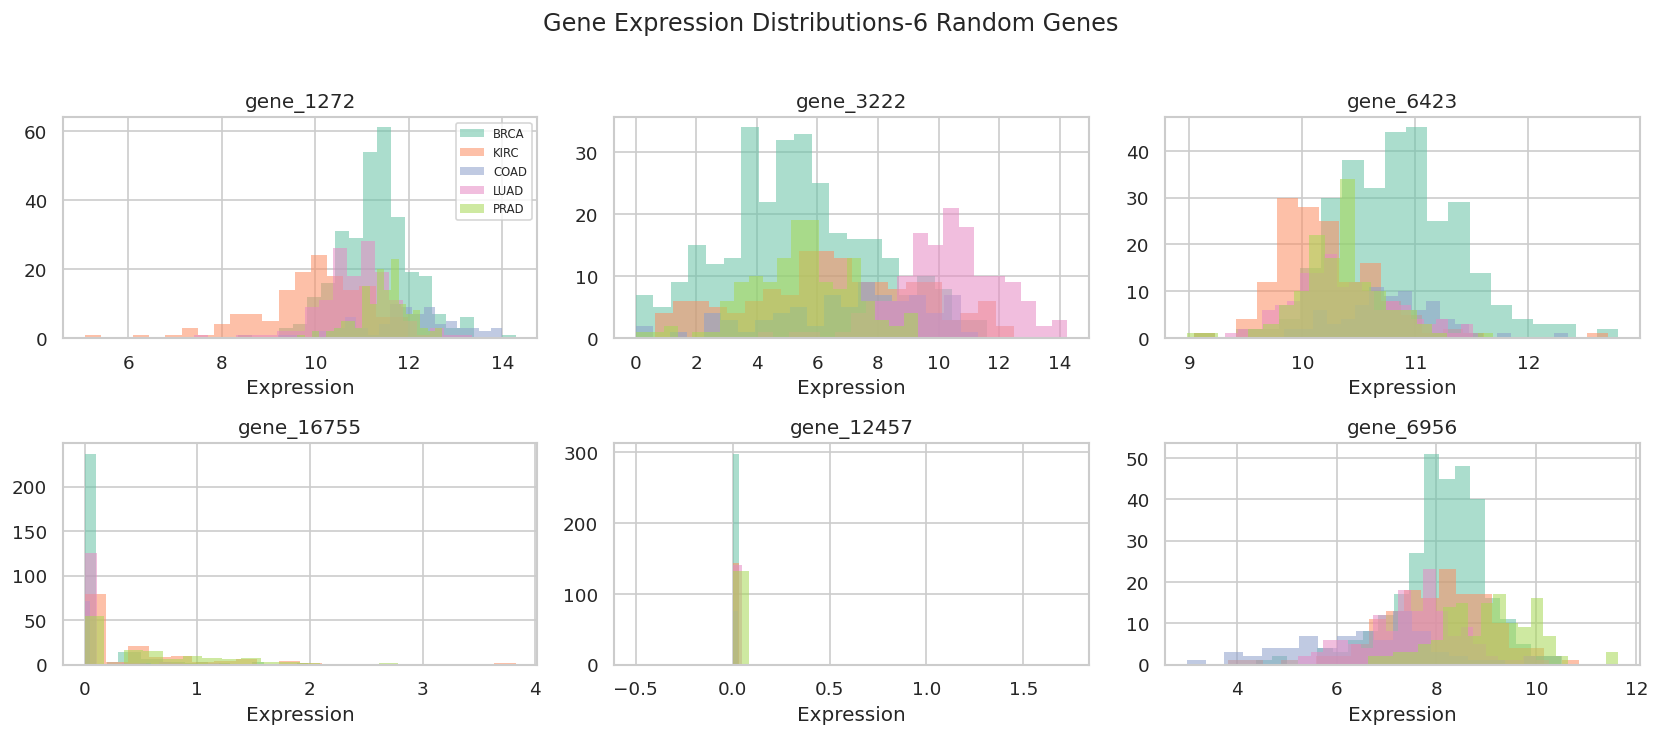

In [6]:
np.random.seed(42)
sample_genes = np.random.choice(X_raw.columns, 6, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()
for idx, gene in enumerate(sample_genes):
    for ct, color in zip(CANCER_TYPES, COLORS):
        axes[idx].hist(X_raw.loc[y==ct, gene], bins=20, alpha=0.55,
                       label=ct, color=color, edgecolor='none')
    axes[idx].set_title(f'{gene}')
    axes[idx].set_xlabel('Expression')
    if idx == 0: axes[idx].legend(fontsize=7)
plt.suptitle('Gene Expression Distributions-6 Random Genes', y=1.02)
plt.tight_layout(); plt.show()


---
## 4.  Pre-processing

1. **Label encoding** → integers for sklearn
2. **Variance filtering** → remove near-zero-variance genes (threshold=0.05)
3. **Stratified 80/20 split**
4. **StandardScaler** → fit on train only, apply to both
5. **SMOTE** → oversample minority classes to equal size

In [7]:
le    = LabelEncoder()
y_enc = le.fit_transform(y)
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))


Label mapping: {'BRCA': np.int64(0), 'COAD': np.int64(1), 'KIRC': np.int64(2), 'LUAD': np.int64(3), 'PRAD': np.int64(4)}


In [8]:
vt             = VarianceThreshold(threshold=0.05)
X_vt           = vt.fit_transform(X_raw)
retained_genes = X_raw.columns[vt.get_support()].tolist()
print(f'Before : {X_raw.shape[1]:,} genes')
print(f'After  : {X_vt.shape[1]:,} genes retained')
print(f'Removed: {X_raw.shape[1]-X_vt.shape[1]:,}')


Before : 20,531 genes
After  : 19,536 genes retained
Removed: 995


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vt, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}')


Train: (640, 19536)  |  Test: (161, 19536)


In [10]:
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train)

print('Before SMOTE:')
for u, c in zip(*np.unique(y_train, return_counts=True)):
    print(f'  {le.classes_[u]}: {c}')
print('\nAfter SMOTE:')
for u, c in zip(*np.unique(y_train_sm, return_counts=True)):
    print(f'  {le.classes_[u]}: {c}')
print(f'\n{len(y_train)} → {len(y_train_sm)} training samples')


Before SMOTE:
  BRCA: 240
  COAD: 62
  KIRC: 116
  LUAD: 113
  PRAD: 109

After SMOTE:
  BRCA: 240
  COAD: 240
  KIRC: 240
  LUAD: 240
  PRAD: 240

640 → 1200 training samples


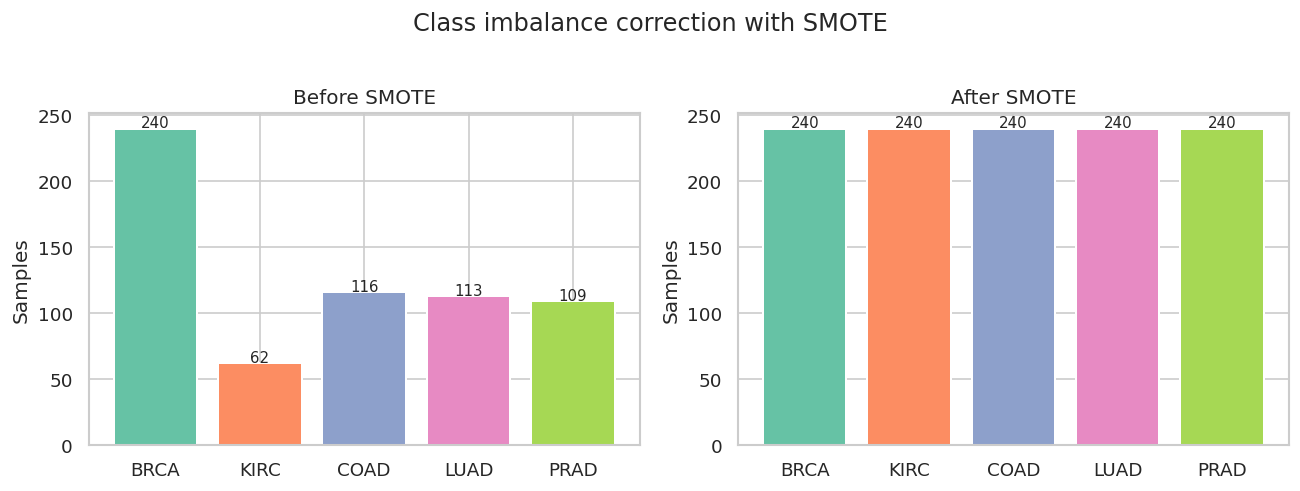

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title in zip(axes,
    [np.bincount(y_train), np.bincount(y_train_sm)],
    ['Before SMOTE', 'After SMOTE']):
    bars = ax.bar(CANCER_TYPES, data, color=COLORS, edgecolor='white', linewidth=1.2)
    ax.set_title(title); ax.set_ylabel('Samples')
    for bar, val in zip(bars, data):
        ax.text(bar.get_x()+bar.get_width()/2, val+1, str(val),
                ha='center', fontsize=9)
plt.suptitle('Class imbalance correction with SMOTE', y=1.02)
plt.tight_layout(); plt.show()


---
## 5.  Principal Component Analysis (PCA)

PCA finds orthogonal axes of maximum variance. **100 components** capture ~97% of all gene expression variance while compressing 14k+ genes into a dense, noise-reduced representation for classification.

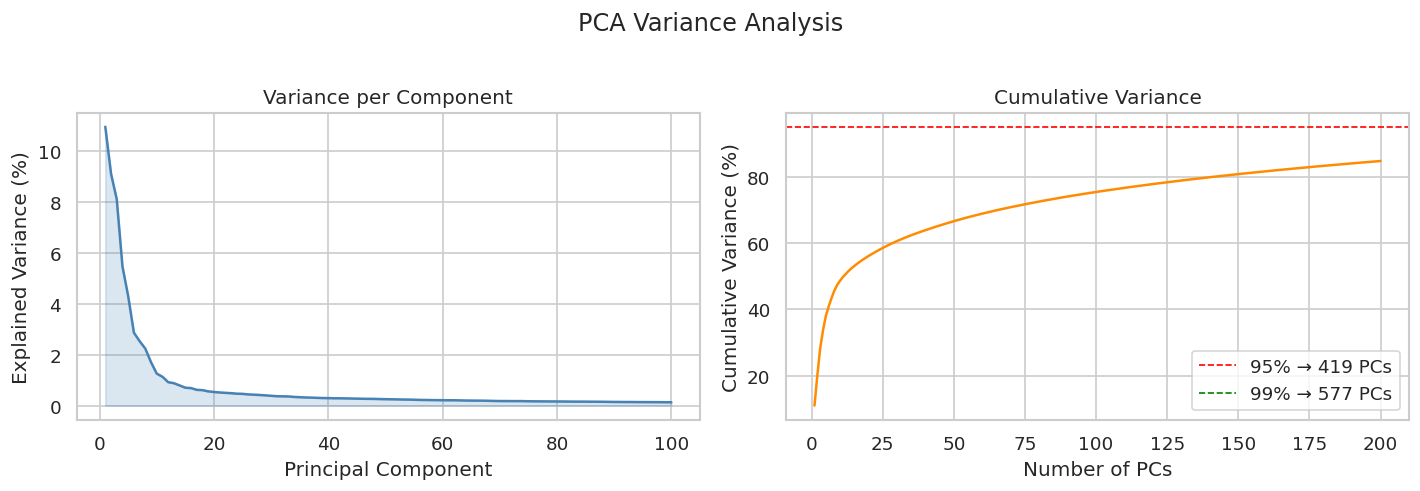

419 PCs → 95%  |  577 PCs → 99%


In [12]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.searchsorted(cum_var, 0.95)+1
n_99 = np.searchsorted(cum_var, 0.99)+1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1,101), pca_full.explained_variance_ratio_[:100]*100,
             color='steelblue', lw=1.5)
axes[0].fill_between(range(1,101),
                     pca_full.explained_variance_ratio_[:100]*100,
                     alpha=0.2, color='steelblue')
axes[0].set_title('Variance per Component')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance (%)')

axes[1].plot(range(1,201), cum_var[:200]*100, color='darkorange', lw=1.5)
axes[1].axhline(95, color='red',   ls='--', lw=1, label=f'95% → {n_95} PCs')
axes[1].axhline(99, color='green', ls='--', lw=1, label=f'99% → {n_99} PCs')
axes[1].set_title('Cumulative Variance')
axes[1].set_xlabel('Number of PCs'); axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

plt.suptitle('PCA Variance Analysis', y=1.02)
plt.tight_layout(); plt.show()
print(f'{n_95} PCs → 95%  |  {n_99} PCs → 99%')


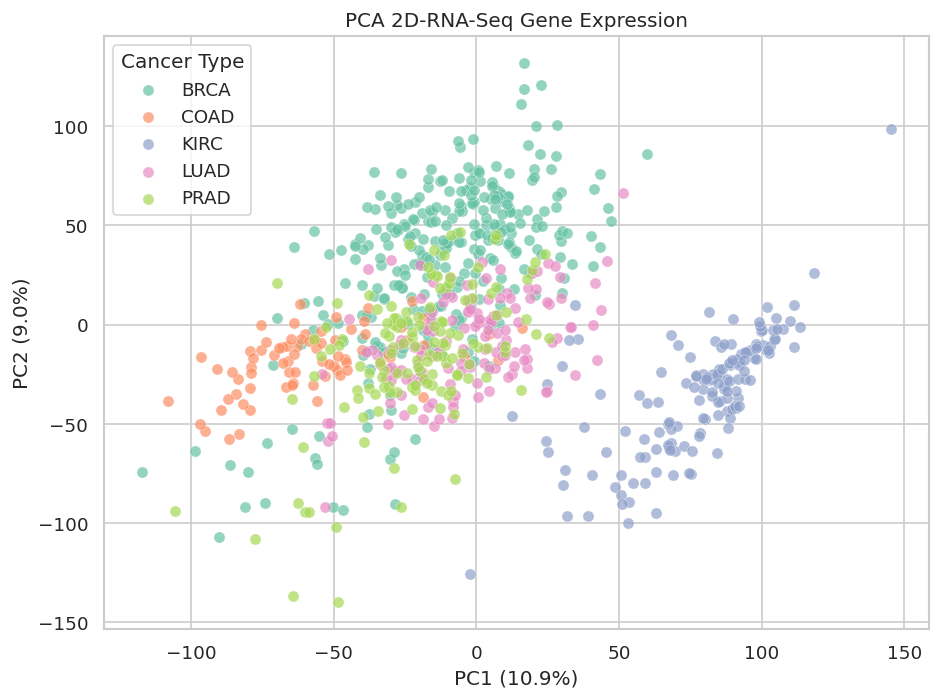

In [13]:
X_all_sc = scaler.transform(X_vt)
pca_2d   = PCA(n_components=2, random_state=42)
X_pca2   = pca_2d.fit_transform(X_all_sc)

plt.figure(figsize=(8, 6))
for ct, color in zip(le.classes_, COLORS):
    mask = y==ct
    plt.scatter(X_pca2[mask,0], X_pca2[mask,1],
                label=ct, color=color, alpha=0.7, s=45,
                edgecolors='white', linewidths=0.3)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA 2D-RNA-Seq Gene Expression')
plt.legend(title='Cancer Type')
plt.tight_layout(); plt.show()


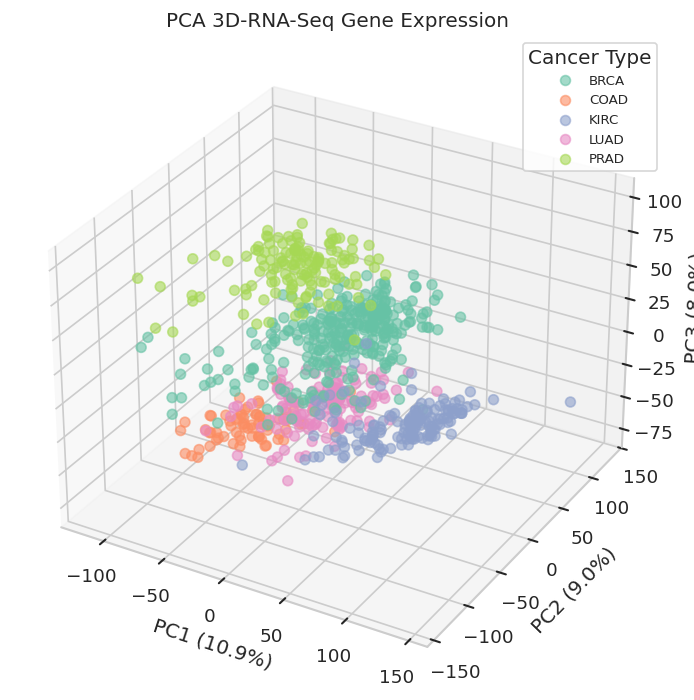

In [14]:
pca_3d = PCA(n_components=3, random_state=42)
X_pca3 = pca_3d.fit_transform(X_all_sc)

fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection='3d')
for ct, color in zip(le.classes_, COLORS):
    mask = y==ct
    ax.scatter(X_pca3[mask,0], X_pca3[mask,1], X_pca3[mask,2],
               label=ct, color=color, alpha=0.6, s=35)
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('PCA 3D-RNA-Seq Gene Expression')
ax.legend(title='Cancer Type', fontsize=8)
plt.tight_layout(); plt.show()


---
## 6.  UMAP-Non-linear dimensionality reduction

Unlike PCA, UMAP preserves local neighbourhood structure. Where PCA shows overlapping clusters in 2D, UMAP reveals tight, well-separated islands confirming that non-linear gene co-expression patterns exist.

In [15]:
print('Computing UMAP (~1-2 min)...')
reducer = umap_.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap2 = reducer.fit_transform(X_all_sc)
print(f'Done. Shape: {X_umap2.shape}')


Computing UMAP (~1-2 min)...
Done. Shape: (801, 2)


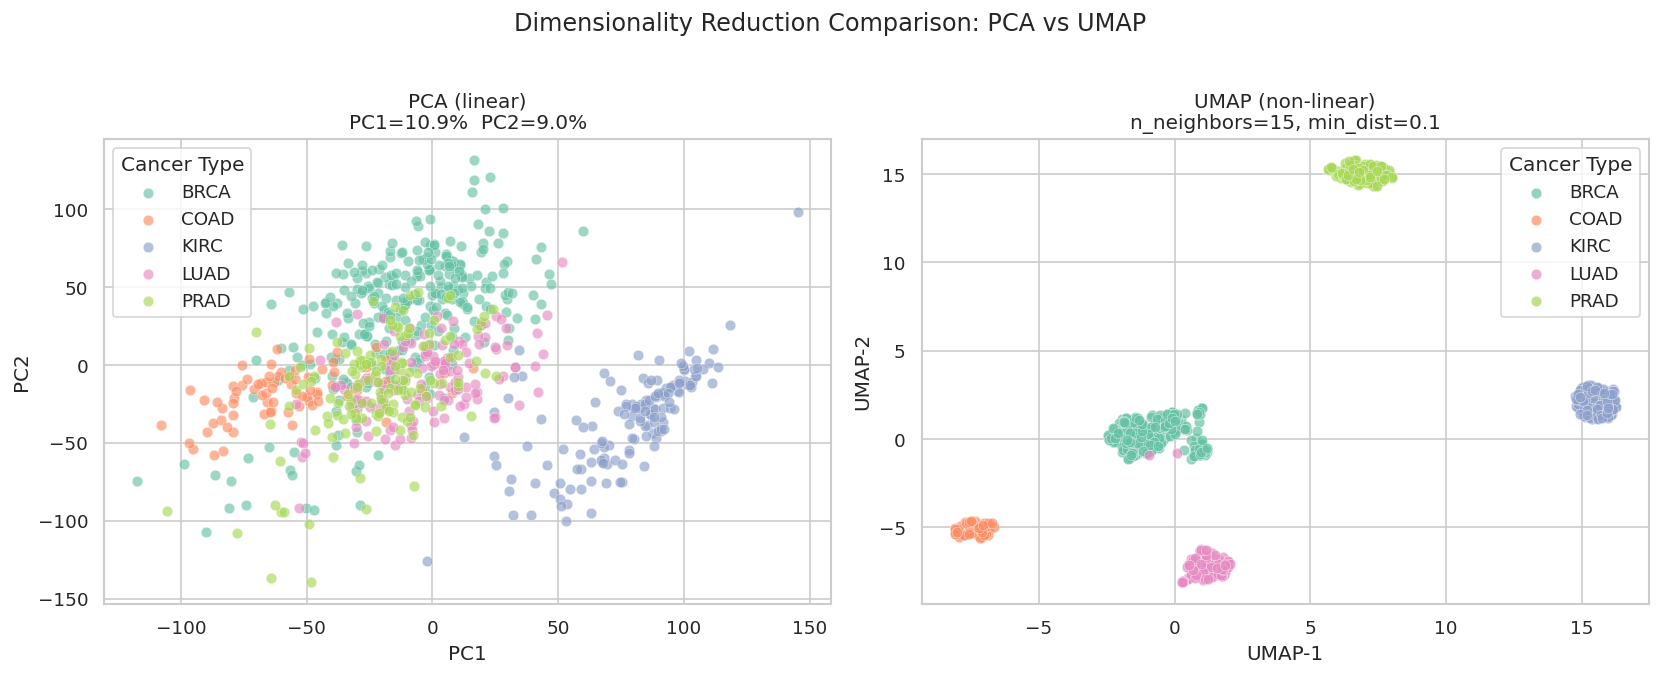

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ct, color in zip(le.classes_, COLORS):
    mask = y==ct
    axes[0].scatter(X_pca2[mask,0], X_pca2[mask,1],
                    label=ct, color=color, alpha=0.65, s=40,
                    edgecolors='white', linewidths=0.3)
    axes[1].scatter(X_umap2[mask,0], X_umap2[mask,1],
                    label=ct, color=color, alpha=0.7, s=40,
                    edgecolors='white', linewidths=0.3)

axes[0].set_title(f'PCA (linear)\nPC1={pca_2d.explained_variance_ratio_[0]*100:.1f}%  '
                  f'PC2={pca_2d.explained_variance_ratio_[1]*100:.1f}%')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(title='Cancer Type')

axes[1].set_title('UMAP (non-linear)\nn_neighbors=15, min_dist=0.1')
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
axes[1].legend(title='Cancer Type')

plt.suptitle('Dimensionality Reduction Comparison: PCA vs UMAP', y=1.02)
plt.tight_layout(); plt.show()


---
## 7.  Model Training

**4 models** trained in two modes:
- **Standard**-original training data (imbalanced)
- **+SMOTE**-oversampled training data (balanced)

Both modes use **100 PCA components** . 5-fold CV on standard mode.

In [17]:
N_COMPONENTS = 100
pca = PCA(n_components=N_COMPONENTS, random_state=42)

X_train_pca    = pca.fit_transform(X_train_sc)
X_test_pca     = pca.transform(X_test_sc)
X_train_sm_pca = pca.transform(X_train_sm)

print(f'PCA: {X_train_sc.shape[1]:,} → {N_COMPONENTS} dims ({pca.explained_variance_ratio_.sum()*100:.1f}% variance)')


PCA: 19,536 → 100 dims (75.2% variance)


In [18]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10,
                                             random_state=42, n_jobs=-1),
    'SVM (RBF)':     SVC(kernel='rbf', C=10, gamma='scale',
                          probability=True, random_state=42),
    'XGBoost':       XGBClassifier(n_estimators=200, max_depth=6,
                                    learning_rate=0.1, eval_metric='mlogloss',
                                    random_state=42, n_jobs=-1),
    'MLP':           MLPClassifier(hidden_layer_sizes=(256,128,64),
                                    activation='relu', max_iter=500,
                                    random_state=42),
}
print(f'{len(models)} models: {list(models.keys())}')


4 models: ['Random Forest', 'SVM (RBF)', 'XGBoost', 'MLP']


In [19]:
results = {}
for name, model in models.items():
    print(f'Training {name}...')

    model.fit(X_train_pca, y_train)
    y_pred   = model.predict(X_test_pca)
    y_proba  = model.predict_proba(X_test_pca)
    acc      = accuracy_score(y_test, y_pred)
    auc_val  = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    model_sm = copy.deepcopy(model)
    model_sm.fit(X_train_sm_pca, y_train_sm)
    y_pred_sm  = model_sm.predict(X_test_pca)
    y_proba_sm = model_sm.predict_proba(X_test_pca)
    acc_sm     = accuracy_score(y_test, y_pred_sm)
    auc_sm     = roc_auc_score(y_test, y_proba_sm, multi_class='ovr', average='macro')

    cv = cross_val_score(model, X_train_pca, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    results[name] = dict(
        model=model, model_sm=model_sm,
        y_pred=y_pred, y_proba=y_proba,
        y_pred_sm=y_pred_sm, y_proba_sm=y_proba_sm,
        accuracy=acc, roc_auc=auc_val,
        accuracy_sm=acc_sm, roc_auc_sm=auc_sm,
        cv_mean=cv.mean(), cv_std=cv.std(),
    )
    print(f'  Standard  Acc={acc:.4f}  AUC={auc_val:.4f}  CV={cv.mean():.4f}±{cv.std():.4f}')
    print(f'  +SMOTE    Acc={acc_sm:.4f}  AUC={auc_sm:.4f}')


Training Random Forest...
  Standard  Acc=0.9689  AUC=0.9988  CV=0.9766±0.0086
  +SMOTE    Acc=0.9814  AUC=0.9988
Training SVM (RBF)...
  Standard  Acc=0.9814  AUC=0.9999  CV=0.9906±0.0115
  +SMOTE    Acc=0.9814  AUC=0.9999
Training XGBoost...
  Standard  Acc=0.9814  AUC=0.9985  CV=0.9828±0.0143
  +SMOTE    Acc=0.9627  AUC=0.9979
Training MLP...
  Standard  Acc=0.9876  AUC=0.9983  CV=0.9875±0.0063
  +SMOTE    Acc=0.9814  AUC=0.9993


---
## 8.  Evaluation & Comparison

In [20]:
summary = pd.DataFrame([{
    'Model':          name,
    'Accuracy':       f"{r['accuracy']:.4f}",
    'Accuracy+SMOTE': f"{r['accuracy_sm']:.4f}",
    'ROC-AUC':        f"{r['roc_auc']:.4f}",
    'ROC-AUC+SMOTE':  f"{r['roc_auc_sm']:.4f}",
    'CV (5-fold)':    f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}",
} for name, r in results.items()]).sort_values('Accuracy+SMOTE', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))


        Model Accuracy Accuracy+SMOTE ROC-AUC ROC-AUC+SMOTE     CV (5-fold)
Random Forest   0.9689         0.9814  0.9988        0.9988 0.9766 ± 0.0086
    SVM (RBF)   0.9814         0.9814  0.9999        0.9999 0.9906 ± 0.0115
          MLP   0.9876         0.9814  0.9983        0.9993 0.9875 ± 0.0063
      XGBoost   0.9814         0.9627  0.9985        0.9979 0.9828 ± 0.0143


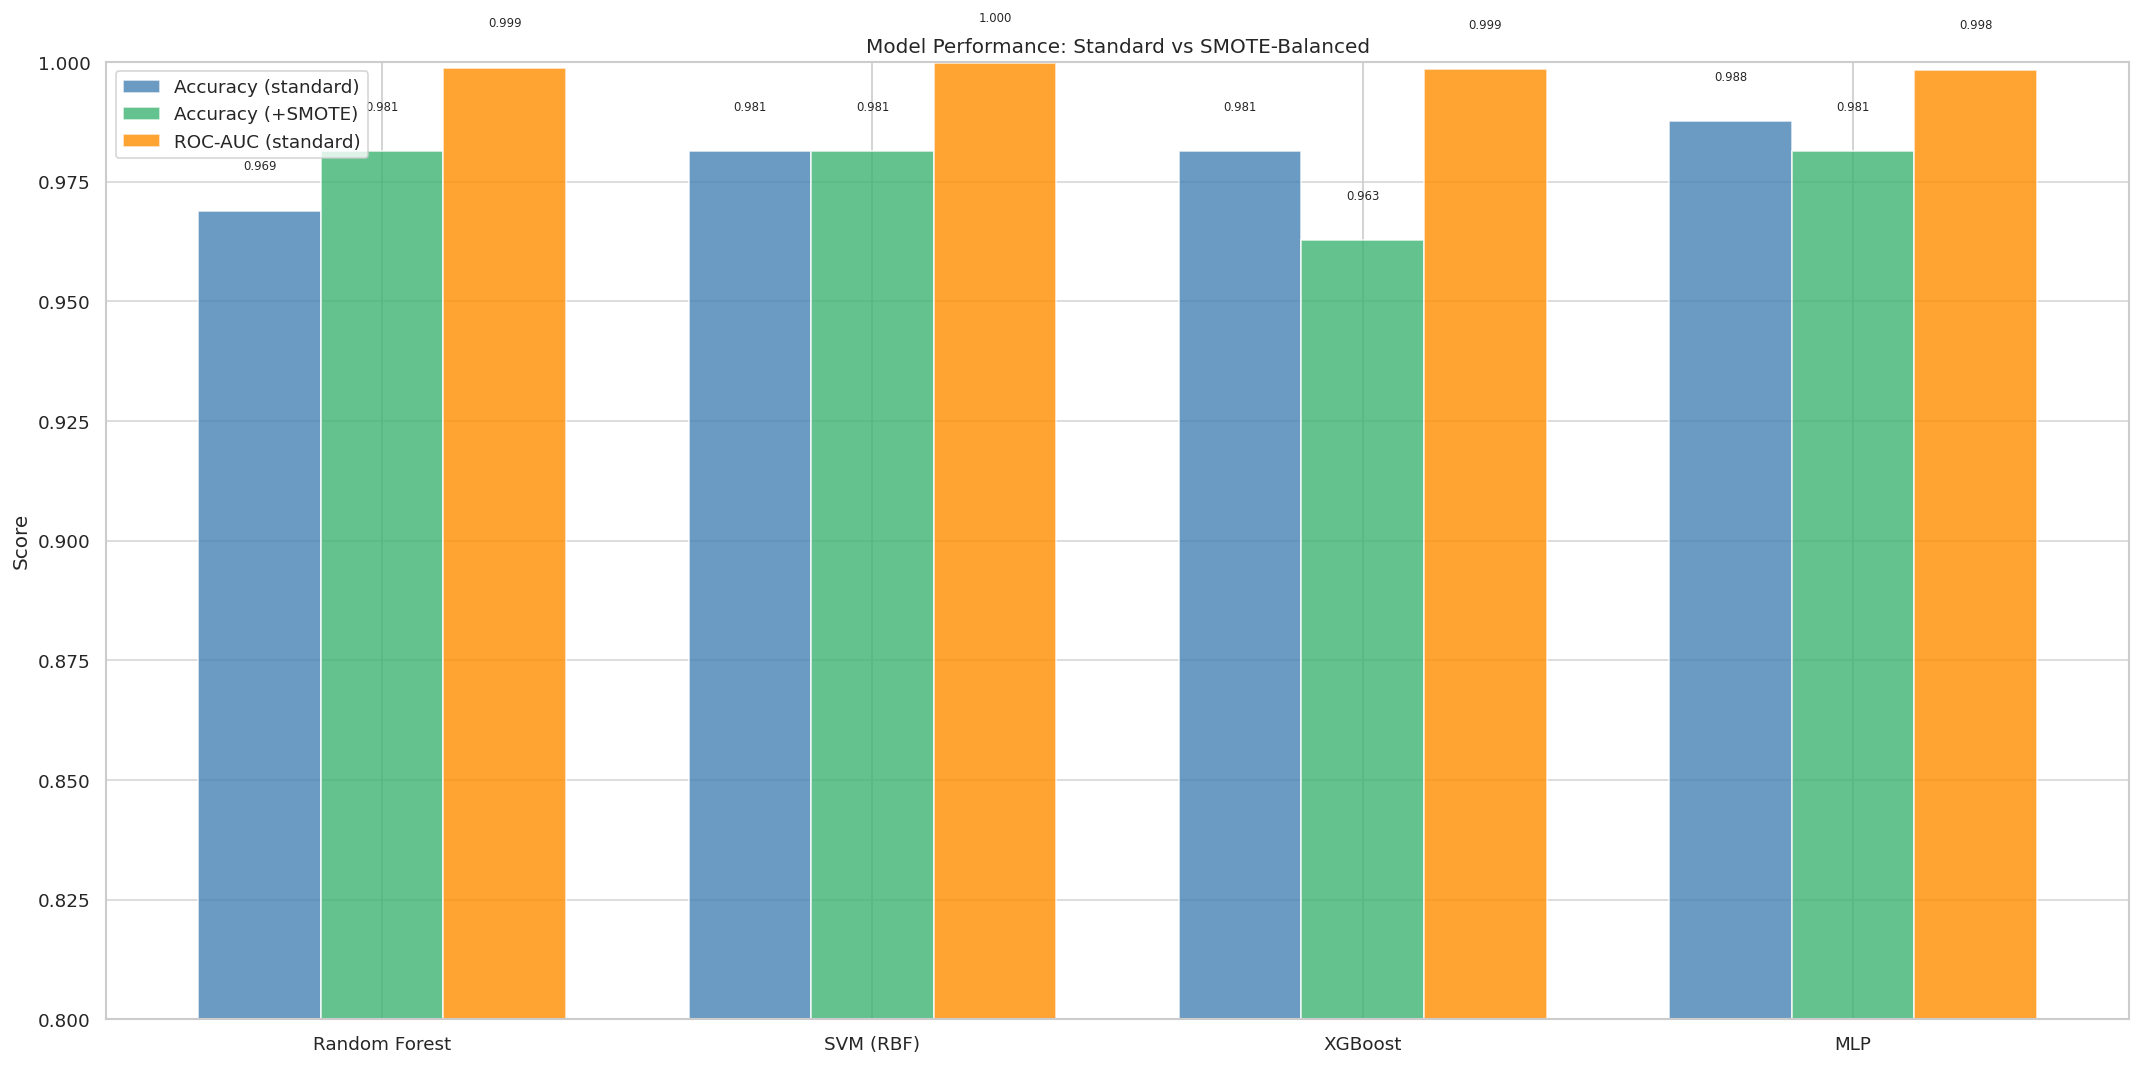

In [21]:
names   = list(results.keys())
accs    = [results[n]['accuracy']    for n in names]
accs_sm = [results[n]['accuracy_sm'] for n in names]
aucs    = [results[n]['roc_auc']     for n in names]

x = np.arange(len(names)); w = 0.25
fig, ax = plt.subplots(figsize=(18, 9))
b1 = ax.bar(x-w,   accs,    w, label='Accuracy (standard)', color='steelblue',      alpha=0.8)
b2 = ax.bar(x,     accs_sm, w, label='Accuracy (+SMOTE)',   color='mediumseagreen', alpha=0.8)
b3 = ax.bar(x+w,   aucs,    w, label='ROC-AUC (standard)',  color='darkorange',     alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0.80, 1.0); ax.set_ylabel('Score')
ax.set_title('Model Performance: Standard vs SMOTE-Balanced')
ax.legend(); ax.grid(axis='y', alpha=0.8)
for bars in [b1,b2,b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.008, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7)
plt.tight_layout(); plt.show()


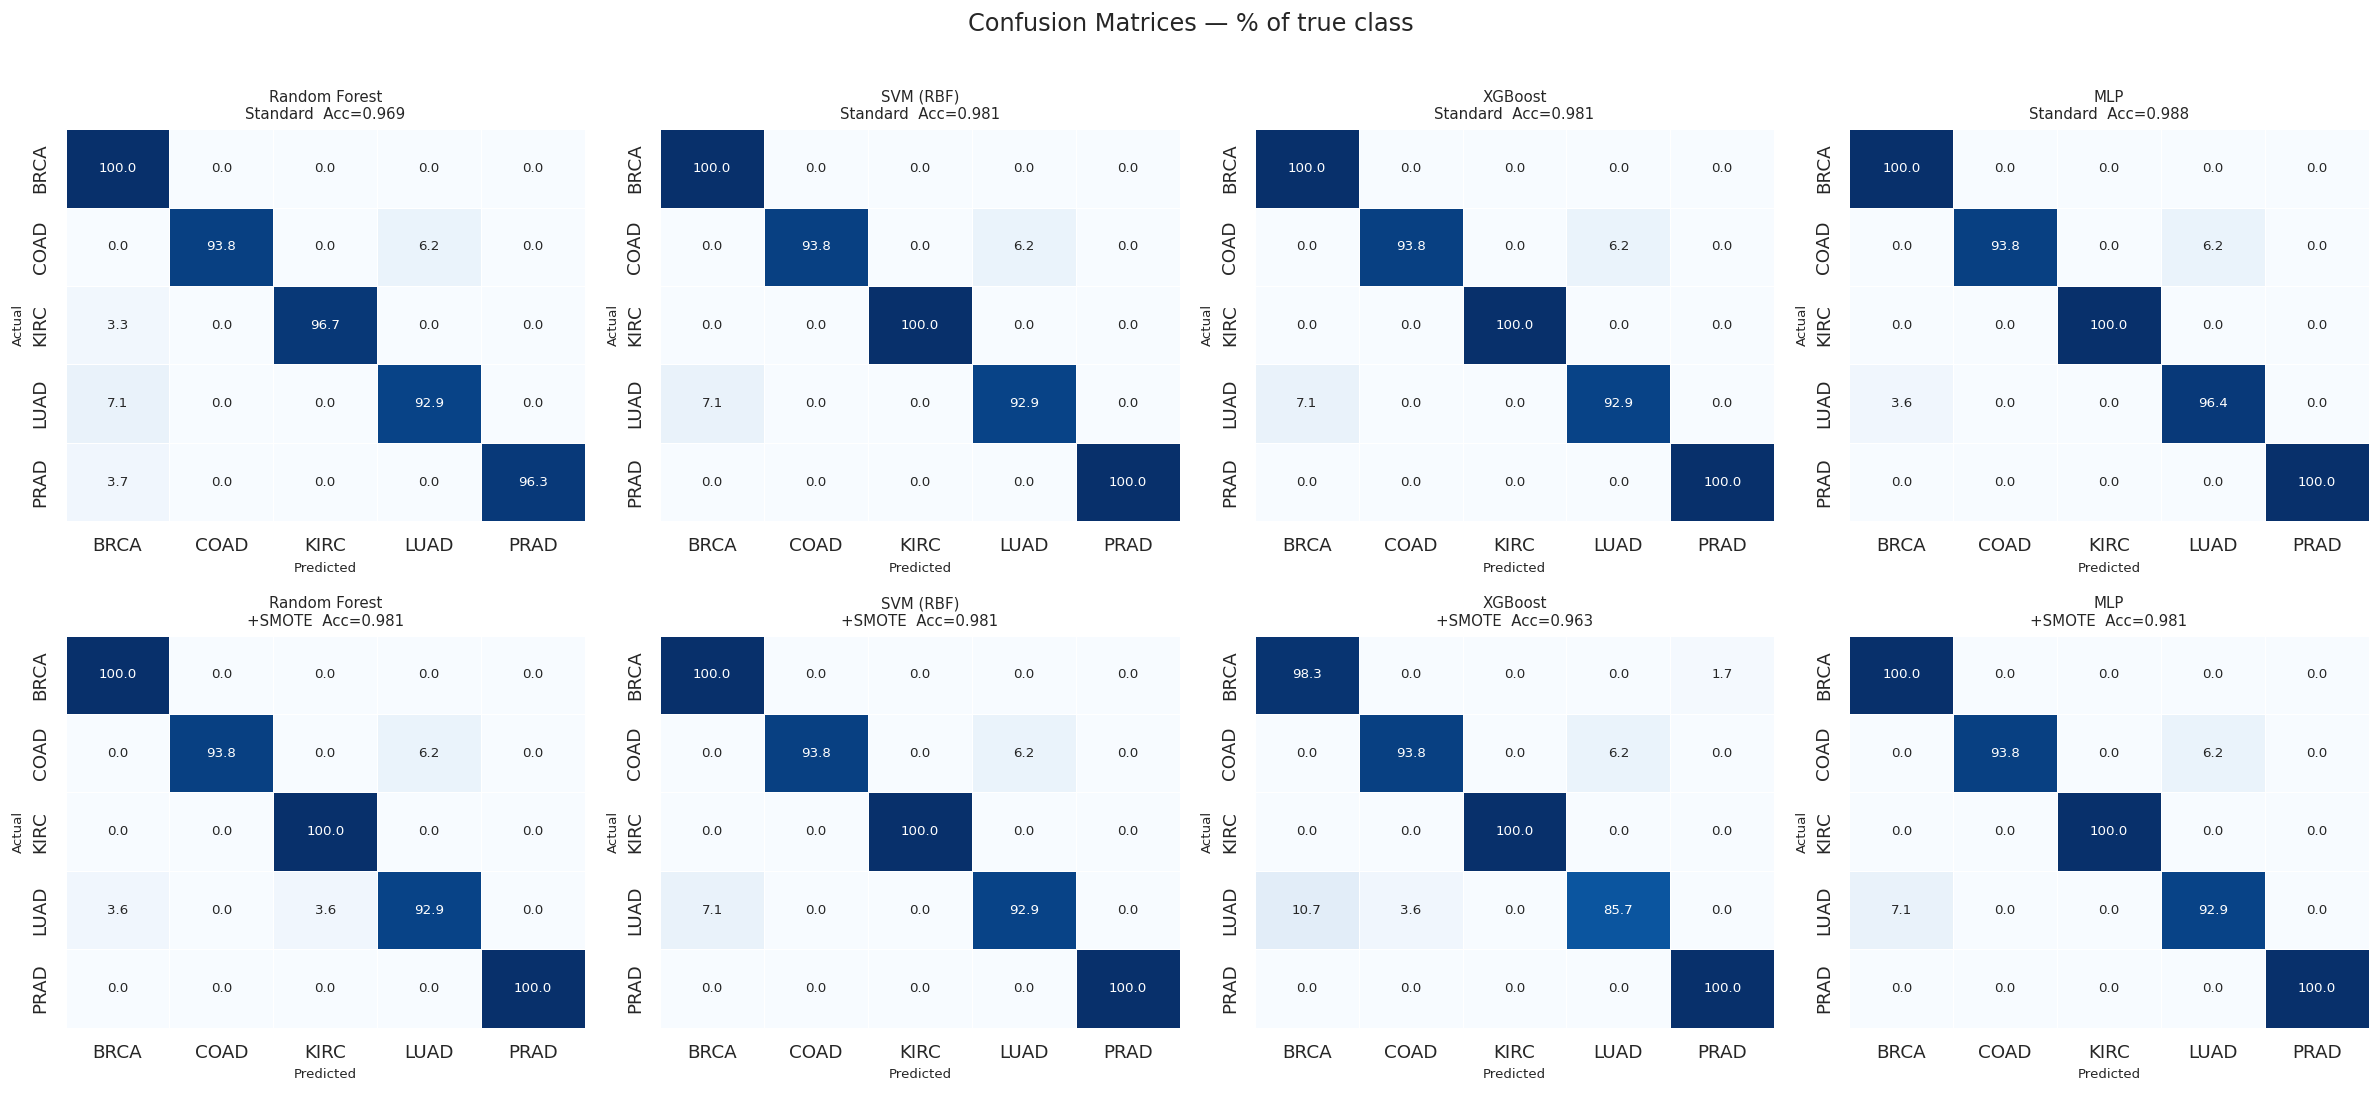

In [22]:
# Confusion matrices — 4 models × 2 modes = 8 heatmaps
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for idx, (name, r) in enumerate(results.items()):
    for row, (pred, suffix, key) in enumerate([
        (r['y_pred'],    'Standard', 'accuracy'),
        (r['y_pred_sm'], '+SMOTE',   'accuracy_sm'),
    ]):
        cm = confusion_matrix(y_test, pred)
        cm_pct = cm.astype(float)/cm.sum(axis=1,keepdims=True)*100
        sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_,
                    ax=axes[row][idx], linewidths=0.4, cbar=False,
                    annot_kws={'size': 8})
        axes[row][idx].set_title(f'{name}\n{suffix}  Acc={r[key]:.3f}', fontsize=9)
        axes[row][idx].set_xlabel('Predicted', fontsize=8)
        axes[row][idx].set_ylabel('Actual',    fontsize=8)
plt.suptitle('Confusion Matrices — % of true class', y=1.01)
plt.tight_layout(); plt.show()


Best model: Random Forest


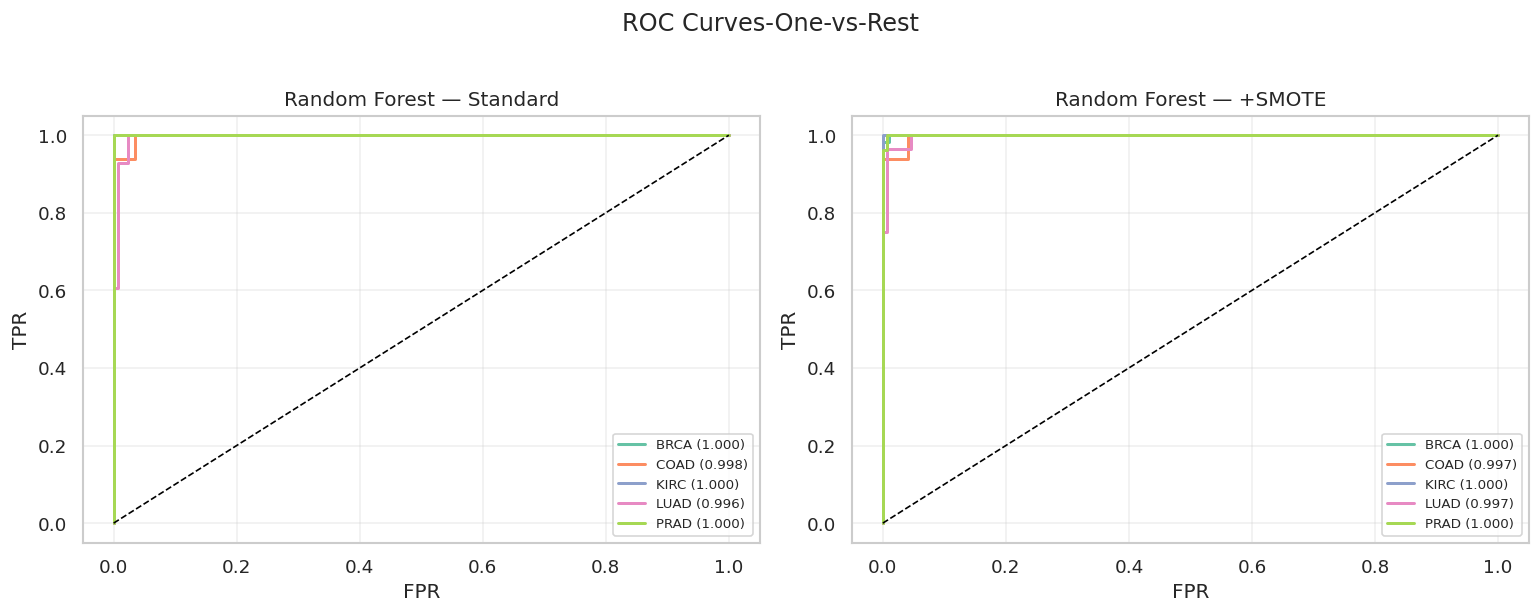

In [23]:
best_name = max(results, key=lambda n: results[n]['accuracy_sm'])
best      = results[best_name]
print(f'Best model: {best_name}')

y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
fig, axes  = plt.subplots(1, 2, figsize=(13, 5))
for ax, proba, title in [
    (axes[0], best['y_proba'],    f'{best_name} — Standard'),
    (axes[1], best['y_proba_sm'], f'{best_name} — +SMOTE'),
]:
    for i, (ct, color) in enumerate(zip(le.classes_, COLORS)):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], proba[:,i])
        ax.plot(fpr, tpr, color=color, lw=1.8, label=f'{ct} ({auc(fpr,tpr):.3f})')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.3)
plt.suptitle('ROC Curves-One-vs-Rest', y=1.02)
plt.tight_layout(); plt.show()


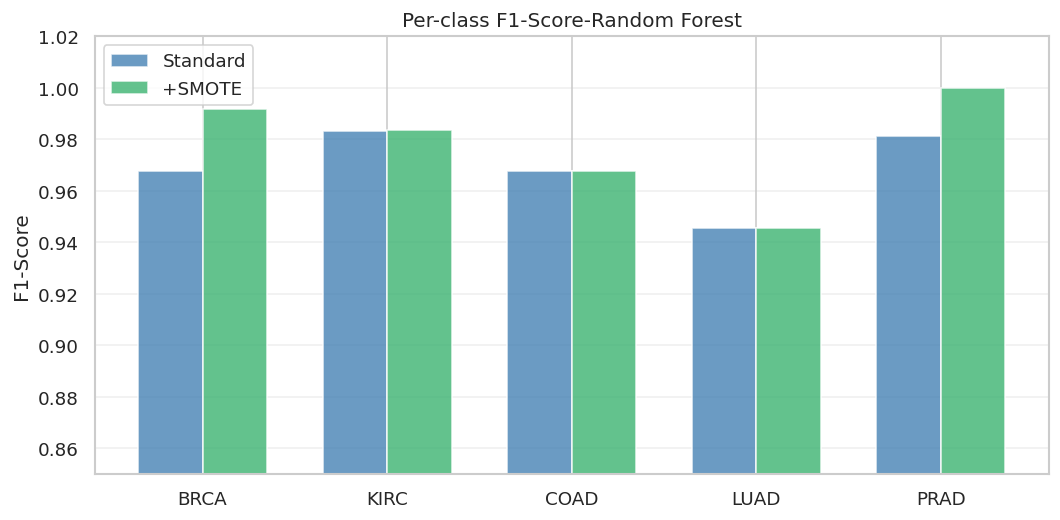


              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      0.94      0.97        16
        KIRC       0.97      1.00      0.98        30
        LUAD       0.96      0.93      0.95        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.98      0.97      0.98       161
weighted avg       0.98      0.98      0.98       161



In [24]:
# Per-class F1 comparison
best_name = max(results, key=lambda n: results[n]['accuracy_sm'])
best      = results[best_name]
rep_std = classification_report(y_test, best['y_pred'],    target_names=le.classes_, output_dict=True)
rep_sm  = classification_report(y_test, best['y_pred_sm'], target_names=le.classes_, output_dict=True)

f1_std = [rep_std[ct]['f1-score'] for ct in CANCER_TYPES]
f1_sm  = [rep_sm[ct]['f1-score']  for ct in CANCER_TYPES]

x = np.arange(len(CANCER_TYPES)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x-w/2, f1_std, w, label='Standard',   color='steelblue',      alpha=0.8)
ax.bar(x+w/2, f1_sm,  w, label='+SMOTE',     color='mediumseagreen', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(CANCER_TYPES)
ax.set_ylim(0.85, 1.02); ax.set_ylabel('F1-Score')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title(f'Per-class F1-Score-{best_name}')
plt.tight_layout(); plt.show()

print(f'\n{classification_report(y_test, best["y_pred_sm"], target_names=le.classes_)}')


---
## 9.  Feature importance via PCA loadings

Random Forest importances live in PCA space. Back-project to gene space:
```
gene_importance = |PCA_components|ᵀ × RF_importances
```

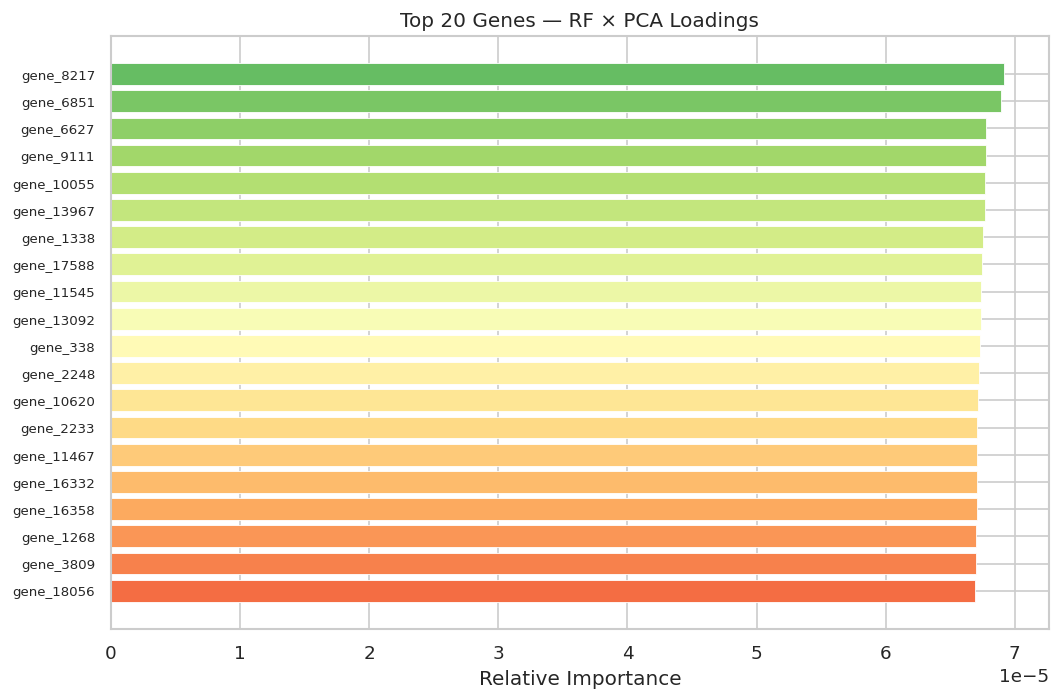

In [25]:
rf_model         = results['Random Forest']['model']
gene_importances = np.abs(pca.components_).T @ rf_model.feature_importances_
gene_importances /= gene_importances.sum()

top_n   = 20
top_idx = np.argsort(gene_importances)[::-1][:top_n]
top_g   = [retained_genes[i] for i in top_idx]
top_imp = gene_importances[top_idx]

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = plt.cm.RdYlGn(np.linspace(0.8, 0.2, top_n))
ax.barh(range(top_n), top_imp[::-1], color=colors_bar[::-1], edgecolor='white', linewidth=0.5)
ax.set_yticks(range(top_n)); ax.set_yticklabels(top_g[::-1], fontsize=8)
ax.set_xlabel('Relative Importance')
ax.set_title(f'Top {top_n} Genes — RF × PCA Loadings')
plt.tight_layout(); plt.show()


---
## 10. 🔍 SHAP Analysis / Gene-level explanations

XGBoost retrained on **full gene space** (no PCA compression) so every SHAP value maps directly to a named gene.

> SHAP ≥0.41 returns shape `(samples, genes, classes)` — a 3D array.


In [26]:
print('Retraining XGBoost on full gene space...')
xgb_shap = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                           eval_metric='mlogloss', random_state=42, n_jobs=-1)
xgb_shap.fit(X_train_sm, y_train_sm)
print(f'Accuracy (full gene, SMOTE): {accuracy_score(y_test, xgb_shap.predict(X_test_sc)):.4f}')
gene_names = retained_genes


Retraining XGBoost on full gene space...
Accuracy (full gene, SMOTE): 0.9876


In [27]:
print('Computing SHAP values (~1-2 min)...')
explainer = shap.TreeExplainer(xgb_shap)
shap_obj  = explainer(X_test_sc)
shap_3d   = shap_obj.values              # (samples, genes, classes)
shap_list = [shap_3d[:,:,i] for i in range(shap_3d.shape[2])]
print(f'Done. Shape: {shap_3d.shape}  (samples × genes × classes)')


Computing SHAP values (~1-2 min)...
Done. Shape: (161, 19536, 5)  (samples × genes × classes)


### SHAP Plot 1-Global gene importance

Top 20 genes ranked by mean |SHAP| averaged across all cancer types and all test samples.

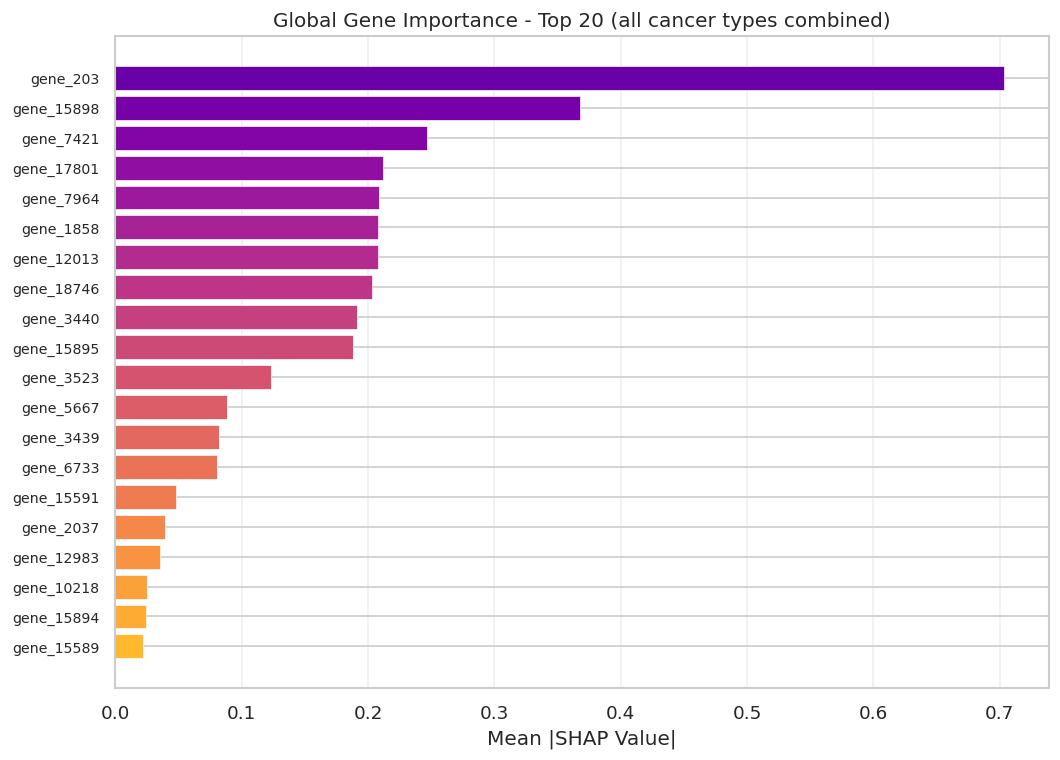

In [28]:
mean_abs = np.abs(shap_3d).mean(axis=(0,2))
top20_idx  = np.argsort(mean_abs)[::-1][:20]
top20_g    = [gene_names[i] for i in top20_idx]
top20_v    = mean_abs[top20_idx]

fig, ax = plt.subplots(figsize=(9, 6.5))
colors_bar = plt.cm.plasma(np.linspace(0.2, 0.85, 20))
ax.barh(range(20), top20_v[::-1], color=colors_bar[::-1], edgecolor='white', linewidth=0.4)
ax.set_yticks(range(20)); ax.set_yticklabels(top20_g[::-1], fontsize=8.5)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Global Gene Importance - Top 20 (all cancer types combined)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


### SHAP Plot 2-Beeswarm per cancer type

Each cancer type gets its own full-sized plot. Red = high expression pushes prediction toward this cancer; Blue = low expression.

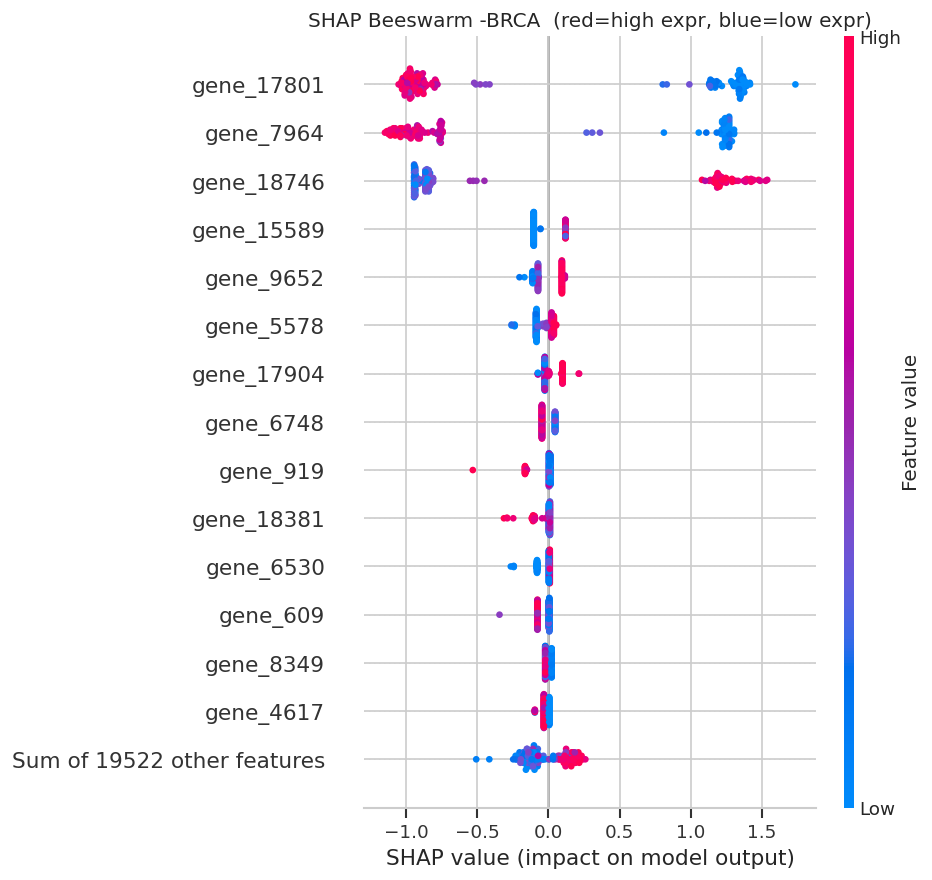

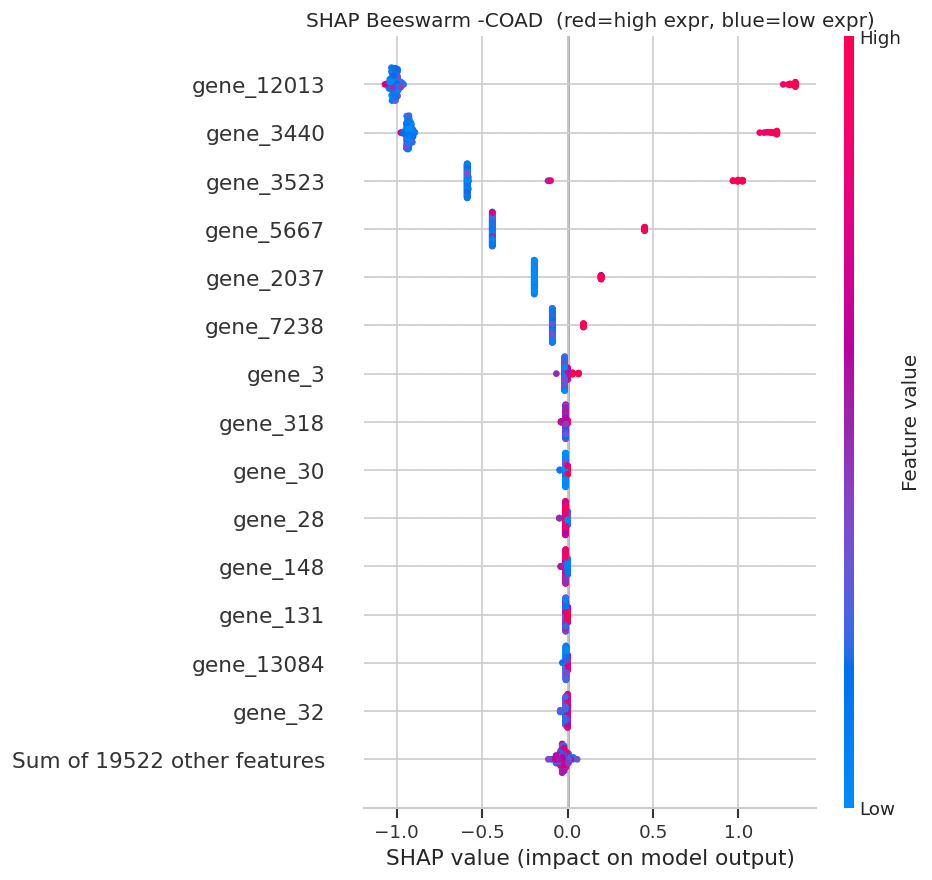

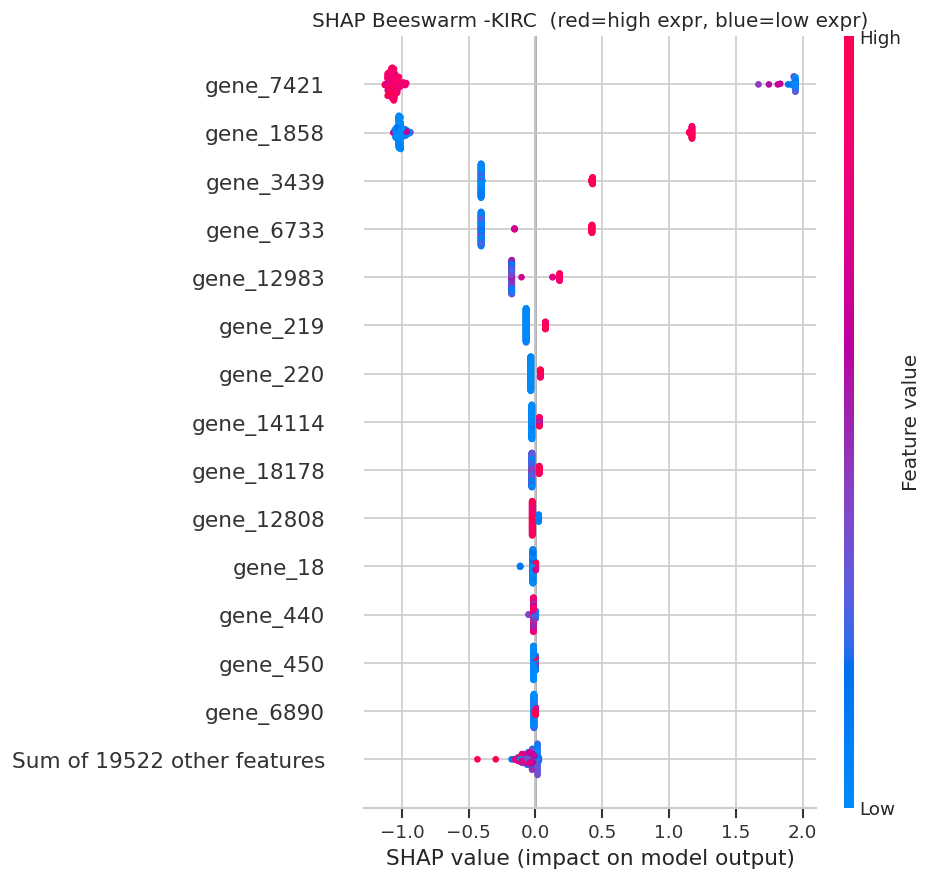

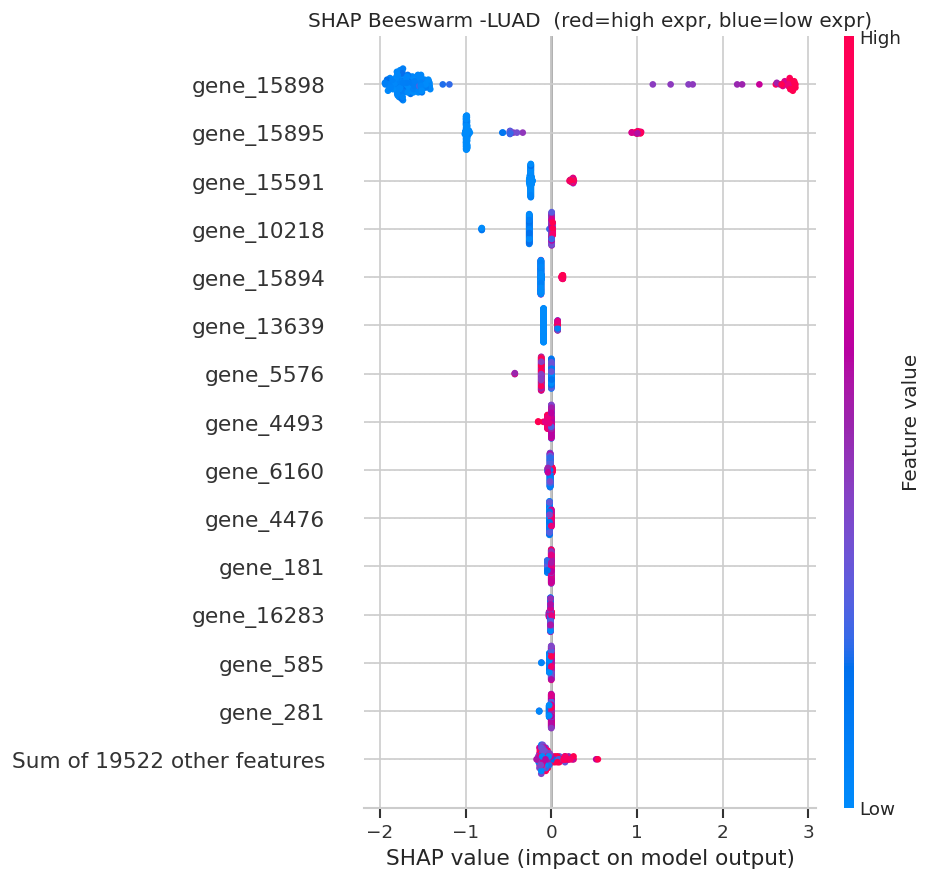

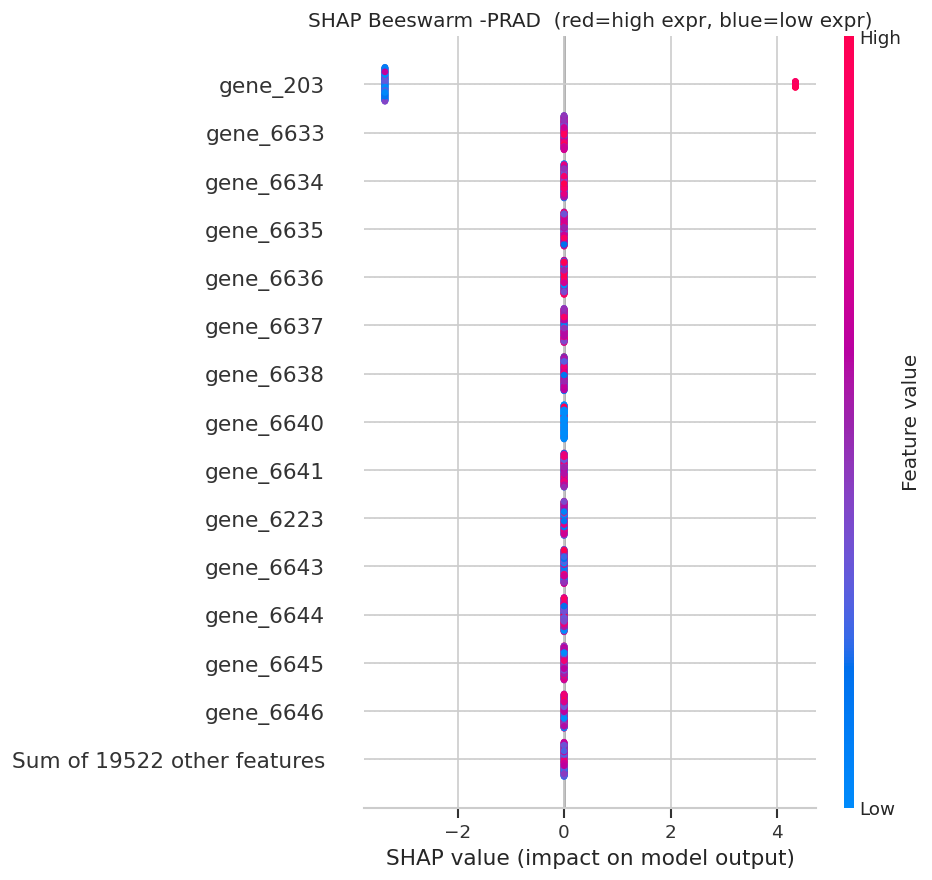

In [29]:
for i, ct in enumerate(le.classes_):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    plt.sca(ax)
    shap_exp = shap.Explanation(
        values        = shap_3d[:, :, i],
        base_values   = explainer.expected_value[i],
        data          = X_test_sc,
        feature_names = gene_names
    )
    shap.plots.beeswarm(shap_exp, max_display=15, show=False)
    ax.set_title(f'SHAP Beeswarm -{ct}  (red=high expr, blue=low expr)')
    plt.tight_layout()
    plt.show()


### SHAP Plot 3-Gene × Cancer type heatmap

Top 25 genes (by max SHAP across classes) shown as a heatmap. Reveals which genes are class-specific vs shared discriminators.

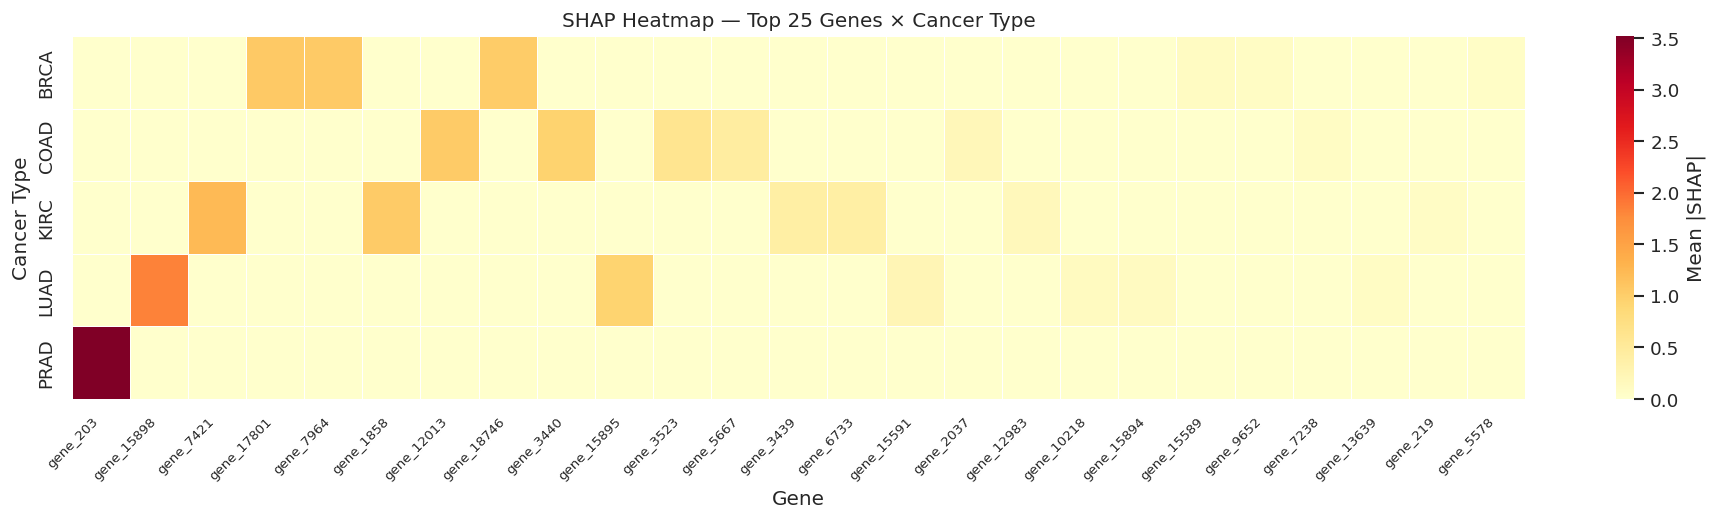

In [30]:
mean_matrix = np.abs(shap_3d).mean(axis=0).T   # (classes, genes)
top25_idx   = np.argsort(mean_matrix.max(axis=0))[::-1][:25]
top25_g     = [gene_names[i] for i in top25_idx]
hm_df       = pd.DataFrame(mean_matrix[:, top25_idx],
                             index=le.classes_, columns=top25_g)

fig, ax = plt.subplots(figsize=(16, 4.5))
sns.heatmap(hm_df, cmap='YlOrRd', annot=False,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Mean |SHAP|'},
            ax=ax)
ax.set_title('SHAP Heatmap — Top 25 Genes × Cancer Type')
ax.set_xlabel('Gene'); ax.set_ylabel('Cancer Type')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout(); plt.show()


### SHAP Plot 4-Waterfall: Individual patient explanations

One representative patient per cancer type. Shows exactly which genes pushed the prediction up or down for that specific patient.

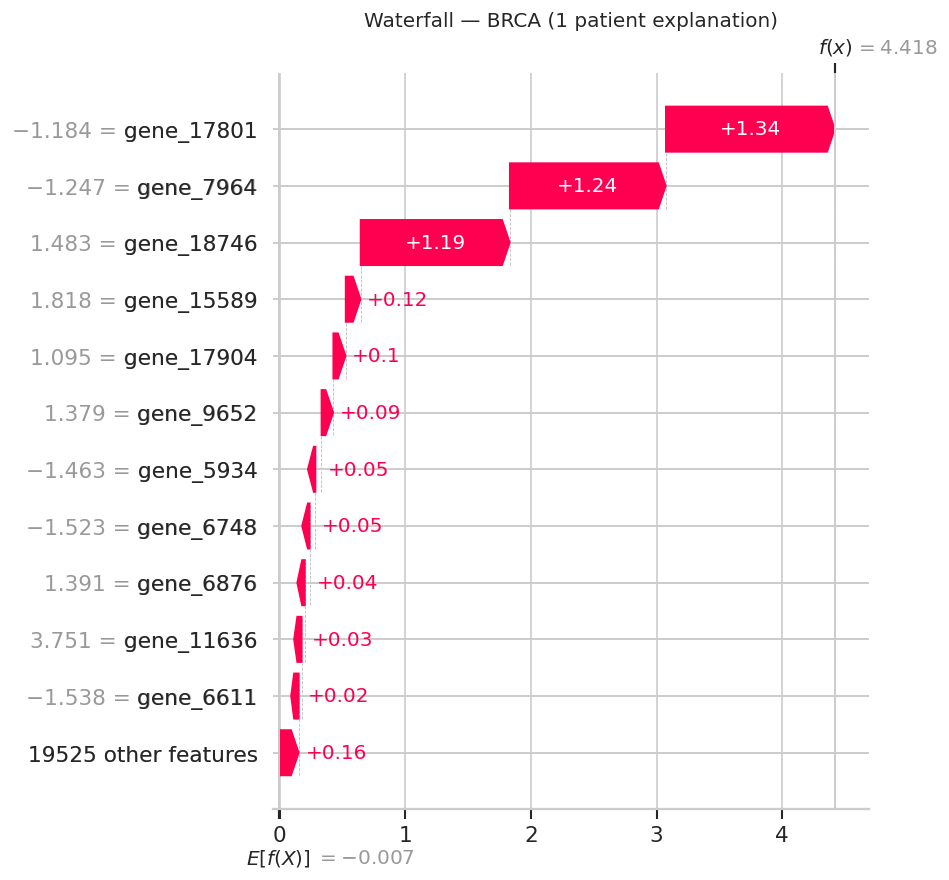

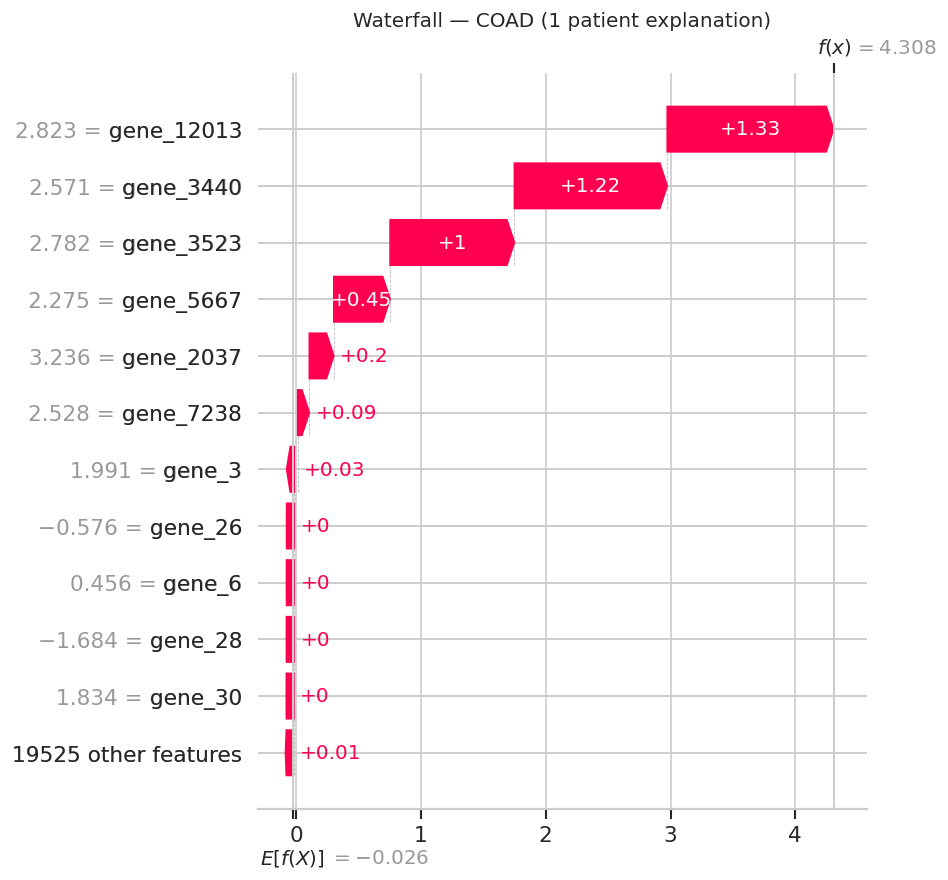

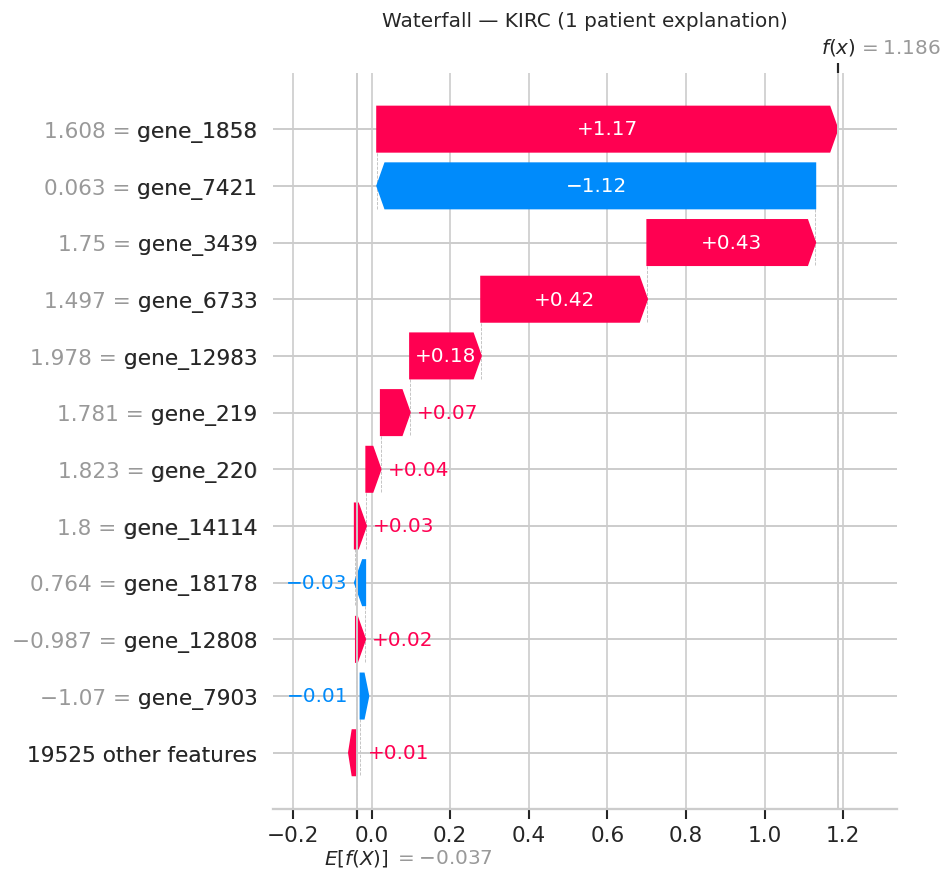

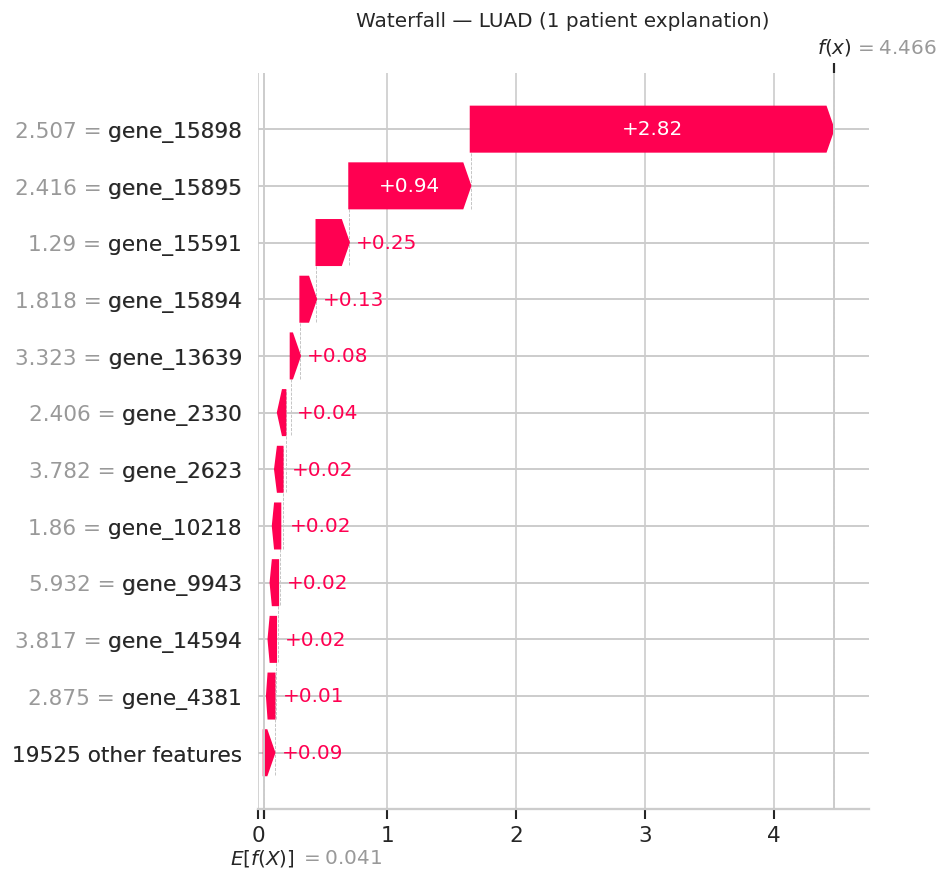

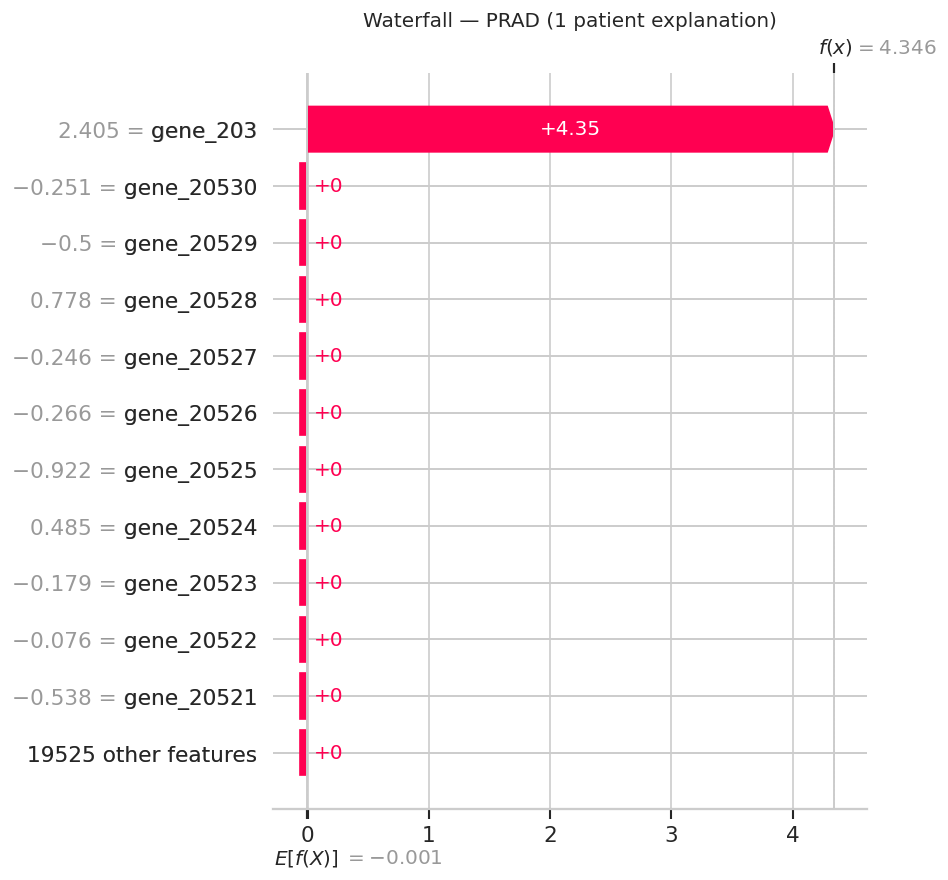

In [31]:
for i, ct in enumerate(le.classes_):
    sample_idx = np.where(y_test == i)[0][0]
    fig, ax = plt.subplots(figsize=(10, 5.5))
    plt.sca(ax)
    shap.plots.waterfall(
        shap.Explanation(
            values        = shap_3d[sample_idx, :, i],
            base_values   = explainer.expected_value[i],
            data          = X_test_sc[sample_idx],
            feature_names = gene_names
        ), max_display=12, show=False
    )
    ax.set_title(f'Waterfall — {ct} (1 patient explanation)')
    plt.tight_layout()
    plt.show()


### SHAP Plot 5-Gene Direction (Over vs Under-expressed)

For each cancer type: which key genes are **over-expressed** (red, positive SHAP) vs **under-expressed** (blue, negative SHAP)?

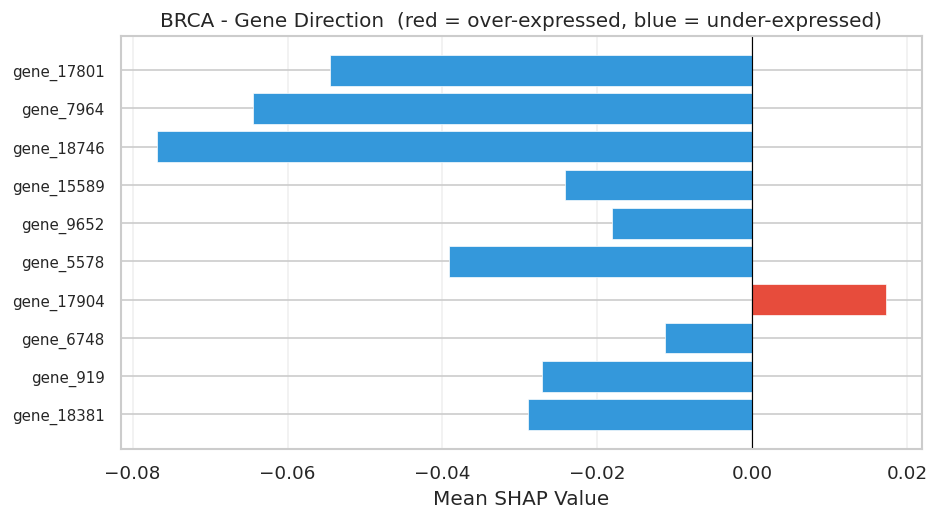

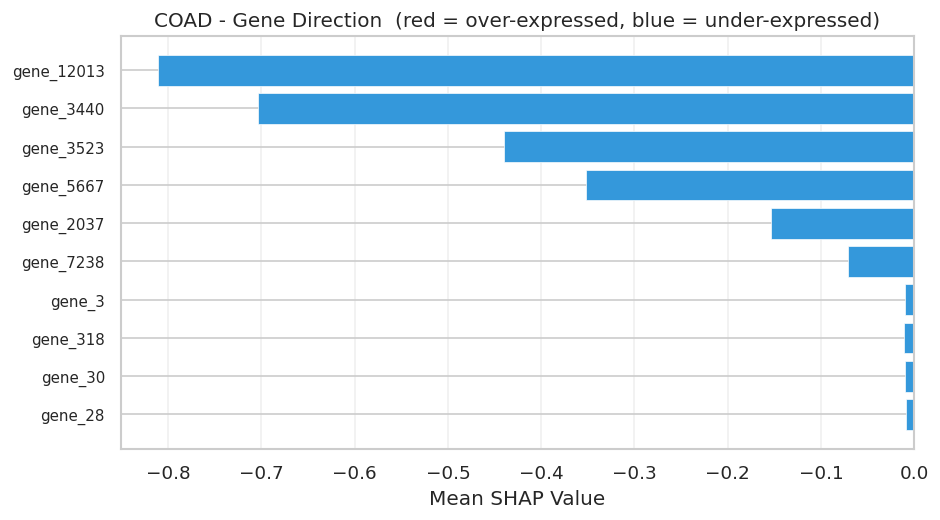

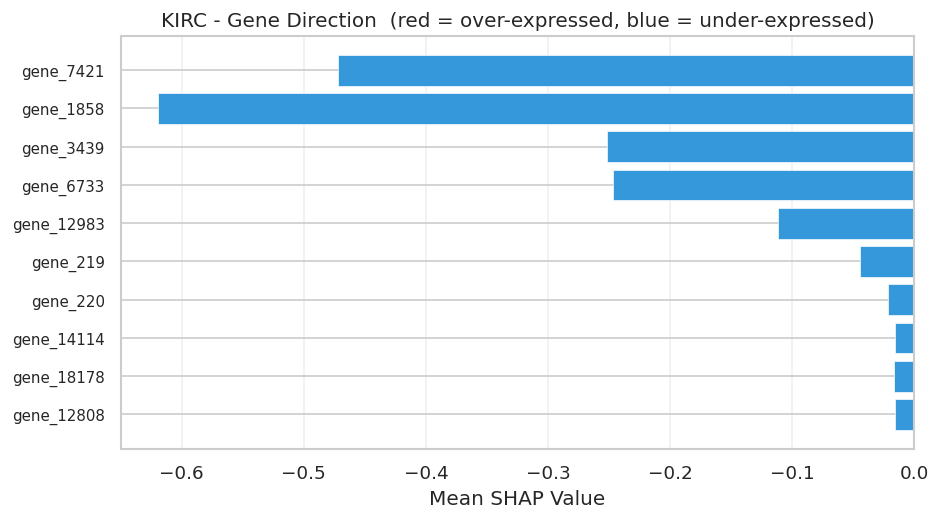

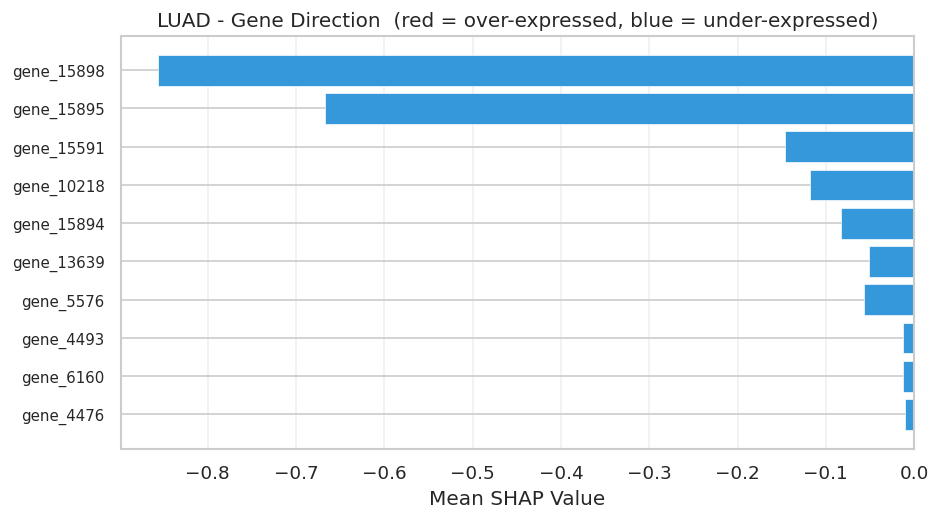

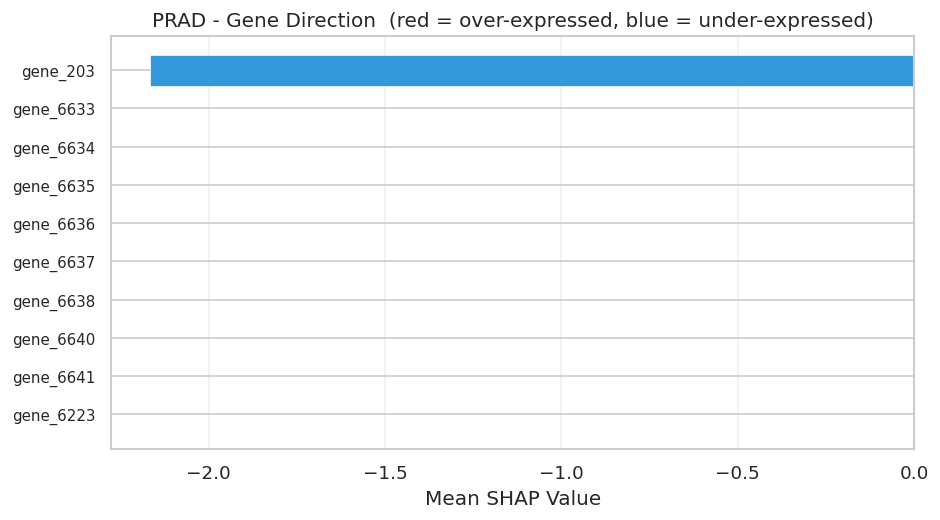

In [32]:
for i, ct in enumerate(le.classes_):
    top8_idx   = np.argsort(np.abs(shap_list[i]).mean(axis=0))[::-1][:10]
    top8_genes = [gene_names[j] for j in top8_idx]
    mean_shap  = shap_list[i].mean(axis=0)[top8_idx]
    colors_dir = ['#e74c3c' if v > 0 else '#3498db' for v in mean_shap]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh(range(10), mean_shap[::-1], color=colors_dir[::-1], edgecolor='white', linewidth=0.4)
    ax.set_yticks(range(10)); ax.set_yticklabels(top8_genes[::-1], fontsize=9)
    ax.axvline(0, color='black', lw=0.7)
    ax.set_xlabel('Mean SHAP Value')
    ax.set_title(f'{ct} - Gene Direction  (red = over-expressed, blue = under-expressed)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


---
## 11.  Final summary

In [33]:
best_name = max(results, key=lambda n: results[n]['accuracy_sm'])
best      = results[best_name]

print('=' * 65)
print('   CANCER RNA-SEQ CLASSIFIER — FINAL RESULTS')
print('=' * 65)
print(f'  Dataset        : 801 samples × {X_raw.shape[1]:,} genes (TCGA)')
print(f'  After filter   : {X_vt.shape[1]:,} genes retained')
print(f'  PCA            : {N_COMPONENTS} components → {pca.explained_variance_ratio_.sum()*100:.1f}% variance')
print()
print('  Model comparison (Standard → +SMOTE):')
for name, r in sorted(results.items(), key=lambda x: -x[1]['accuracy_sm']):
    d = r['accuracy_sm']-r['accuracy']
    print(f'  {name:<18} {r["accuracy"]:.4f} → {r["accuracy_sm"]:.4f} ({d:+.4f})  AUC {r["roc_auc_sm"]:.4f}')
print()
print(f'  Best model  : {best_name}')
print(f'  Accuracy    : {best["accuracy_sm"]:.4f}')
print(f'  ROC-AUC     : {best["roc_auc_sm"]:.4f}')
print()
print('=' * 65)


   CANCER RNA-SEQ CLASSIFIER — FINAL RESULTS
  Dataset        : 801 samples × 20,531 genes (TCGA)
  After filter   : 19,536 genes retained
  PCA            : 100 components → 75.2% variance

  Model comparison (Standard → +SMOTE):
  Random Forest      0.9689 → 0.9814 (+0.0124)  AUC 0.9988
  SVM (RBF)          0.9814 → 0.9814 (+0.0000)  AUC 0.9999
  MLP                0.9876 → 0.9814 (-0.0062)  AUC 0.9993
  XGBoost            0.9814 → 0.9627 (-0.0186)  AUC 0.9979

  Best model  : Random Forest
  Accuracy    : 0.9814
  ROC-AUC     : 0.9988



Project-1 Cancer Type Classification from RNA-Seq Gene Expression
*Bioprocess & Bioengineering Portfolio | TCGA RNA-Seq | RF · SVM · XGBoost · MLP | SHAP*


